# ДЗ, тема 4. Прогнозування міцності бетону

Регресія на датасеті Concrete Compressive Strength: 1030 зразків, 8 числових ознак
(склад суміші в кг/м3 та вік у днях), ціль Strength у МПа. Будую повнозв'язну
нейромережу на PyTorch і дивлюсь, які фактори найбільше впливають на міцність.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available()
                      else "mps" if torch.backends.mps.is_available()
                      else "cpu")
print(device)

mps


## Дані

In [2]:
CSV_NAME = "ConcreteStrengthData.csv"

if os.path.exists(CSV_NAME):
    csv_path = CSV_NAME
else:
    from google.colab import drive
    drive.mount("/content/drive")
    csv_path = "/content/drive/MyDrive/" + CSV_NAME

df = pd.read_csv(csv_path)
df.columns = df.columns.str.strip()
print(df.shape)
df.head()

(1030, 9)


,CementComponent,BlastFurnaceSlag,FlyAshComponent,WaterComponent,SuperplasticizerComponent,CoarseAggregateComponent,FineAggregateComponent,AgeInDays,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


## Попередній аналіз

In [3]:
df.info()
df.describe().round(2)

<class 'pandas.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   CementComponent            1030 non-null   float64
 1   BlastFurnaceSlag           1030 non-null   float64
 2   FlyAshComponent            1030 non-null   float64
 3   WaterComponent             1030 non-null   float64
 4   SuperplasticizerComponent  1030 non-null   float64
 5   CoarseAggregateComponent   1030 non-null   float64
 6   FineAggregateComponent     1030 non-null   float64
 7   AgeInDays                  1030 non-null   int64  
 8   Strength                   1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.6 KB


,CementComponent,BlastFurnaceSlag,FlyAshComponent,WaterComponent,SuperplasticizerComponent,CoarseAggregateComponent,FineAggregateComponent,AgeInDays,Strength
count,1030.00,1030.00,1030.00,1030.00,1030.00,1030.00,1030.00,1030.00,1030.00
mean,281.17,73.90,54.19,181.57,6.20,972.92,773.58,45.66,35.82
std,104.51,86.28,64.00,21.35,5.97,77.75,80.18,63.17,16.71
min,102.00,0.00,0.00,121.80,0.00,801.00,594.00,1.00,2.33
25%,192.38,0.00,0.00,164.90,0.00,932.00,730.95,7.00,23.71
50%,272.90,22.00,0.00,185.00,6.40,968.00,779.50,28.00,34.44
75%,350.00,142.95,118.30,192.00,10.20,1029.40,824.00,56.00,46.14
max,540.00,359.40,200.10,247.00,32.20,1145.00,992.60,365.00,82.60


In [4]:
print("Пропусків:", df.isna().sum().sum())
print("Дублікатів:", df.duplicated().sum())

df = df.drop_duplicates().reset_index(drop=True)
print("Після видалення дублікатів:", df.shape)

Пропусків: 0
Дублікатів: 25
Після видалення дублікатів: (1005, 9)


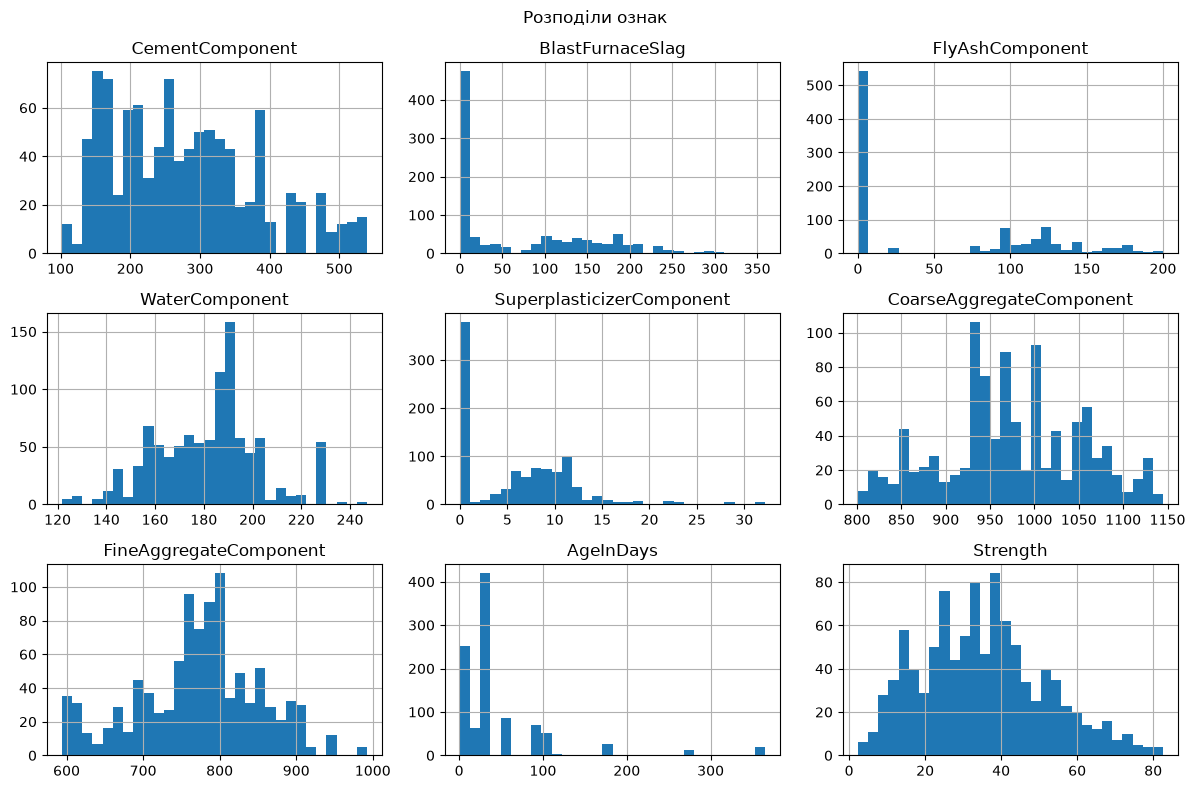

In [5]:
df.hist(figsize=(12, 8), bins=30)
plt.suptitle("Розподіли ознак")
plt.tight_layout()
plt.show()

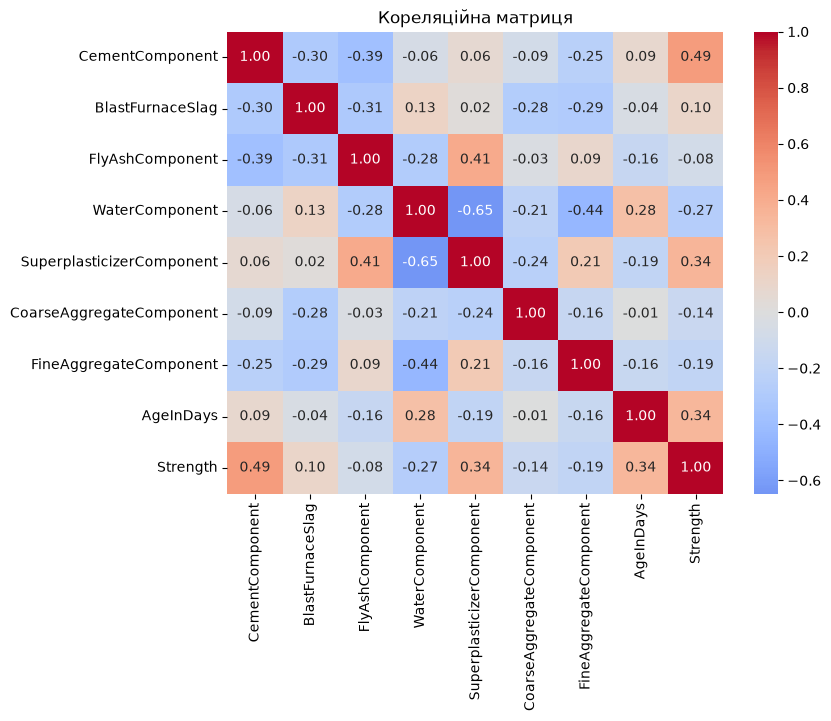

CementComponent              0.49
SuperplasticizerComponent    0.34
AgeInDays                    0.34
WaterComponent              -0.27
FineAggregateComponent      -0.19
CoarseAggregateComponent    -0.14
BlastFurnaceSlag             0.10
FlyAshComponent             -0.08
Name: Strength, dtype: float64

In [6]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Кореляційна матриця")
plt.show()

df.corr()["Strength"].drop("Strength").sort_values(key=abs, ascending=False).round(2)

## Підготовка даних

Розбиття 80/20. StandardScaler навчається тільки на train, тест лише трансформується,
інакше буде витік інформації з тесту. Ціль лишаю в МПа, так метрики читаються напряму.

In [7]:
feature_names = [c for c in df.columns if c != "Strength"]
X = df[feature_names].values.astype(np.float32)
y = df["Strength"].values.astype(np.float32).reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train).astype(np.float32)
X_test = scaler.transform(X_test).astype(np.float32)

X_test_t = torch.tensor(X_test, device=device)
y_test_t = torch.tensor(y_test, device=device)

train_ds = TensorDataset(torch.tensor(X_train), torch.tensor(y_train))
print(X_train.shape, X_test.shape)

(804, 8) (201, 8)


## Модель

Звичайний MLP: вхід 8 ознак, приховані шари з ReLU, один вихідний нейрон без активації,
бо регресія і прогноз може бути будь-яким додатним числом. Розміри шарів передаються
параметром, щоб далі було зручно пробувати різні архітектури.

In [8]:
class ConcreteNet(nn.Module):
    def __init__(self, in_features, hidden=(64, 32)):
        super().__init__()
        layers = []
        prev = in_features
        for h in hidden:
            layers += [nn.Linear(prev, h), nn.ReLU()]
            prev = h
        layers.append(nn.Linear(prev, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

model = ConcreteNet(len(feature_names)).to(device)
print(model)

ConcreteNet(
  (net): Sequential(
    (0): Linear(in_features=8, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)


## Функція втрат, оптимізатор, гіперпараметри

Функція втрат MSELoss. Це стандарт для регресії: квадрат помилки сильно штрафує великі
промахи (недооцінити міцність бетону на 20 МПа набагато гірше, ніж на 2), диференційовна,
і мінімізація MSE напряму означає максимізацію R². MAE тут гірше підходить як loss,
бо однаково цінує великі й малі помилки.

Базова конфігурація за завданням: оптимізатор SGD з momentum 0.9, батч 32, 300 епох.
З lr 0.01 loss вибухав у nan, тому взяв 0.001, з ним навчання стабільне.
Батч 32 для ~800 зразків дає приблизно 26 оновлень ваг за епоху.

In [9]:
criterion = nn.MSELoss()

lr = 0.001
batch_size = 32
epochs = 300

optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)

## Навчання

За епоху: прохід по train батчами (прогноз, loss, backward, крок оптимізатора,
обов'язково zero_grad), потім заміри MSE на тесті в режимі eval без градієнтів.

In [10]:
def train(model, optimizer, epochs, train_loader, log_every=50):
    train_hist, test_hist = [], []
    for epoch in range(1, epochs + 1):
        model.train()
        running = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
            running += loss.item() * len(xb)
        train_hist.append(running / len(train_loader.dataset))

        model.eval()
        with torch.no_grad():
            test_hist.append(criterion(model(X_test_t), y_test_t).item())

        if epoch == 1 or epoch % log_every == 0:
            print(f"епоха {epoch:4d} | train MSE {train_hist[-1]:8.2f} | test MSE {test_hist[-1]:8.2f}")
    return train_hist, test_hist

train_hist, test_hist = train(model, optimizer, epochs, train_loader)

епоха    1 | train MSE   810.67 | test MSE   413.71
епоха   50 | train MSE    17.68 | test MSE    30.20
епоха  100 | train MSE    18.06 | test MSE    33.54
епоха  150 | train MSE    12.23 | test MSE    28.94
епоха  200 | train MSE     8.66 | test MSE    29.64
епоха  250 | train MSE     8.16 | test MSE    25.16
епоха  300 | train MSE     8.50 | test MSE    23.91


## Оцінка

Метрики:

- MSE, те що оптимізуємо, чутлива до великих промахів;
- MAE, середня помилка в МПа, читається напряму в одиницях цілі;
- R², частка поясненої дисперсії, зручна для порівняння моделей (1.0 ідеал, 0 рівень
  прогнозу середнім).

In [11]:
def evaluate(model):
    model.eval()
    with torch.no_grad():
        pred = model(X_test_t).cpu().numpy()
    return {"MSE": mean_squared_error(y_test, pred),
            "MAE": mean_absolute_error(y_test, pred),
            "R2": r2_score(y_test, pred)}, pred

metrics_base, pred_base = evaluate(model)
print({k: round(v, 3) for k, v in metrics_base.items()})

{'MSE': 23.908, 'MAE': 2.965, 'R2': 0.92}


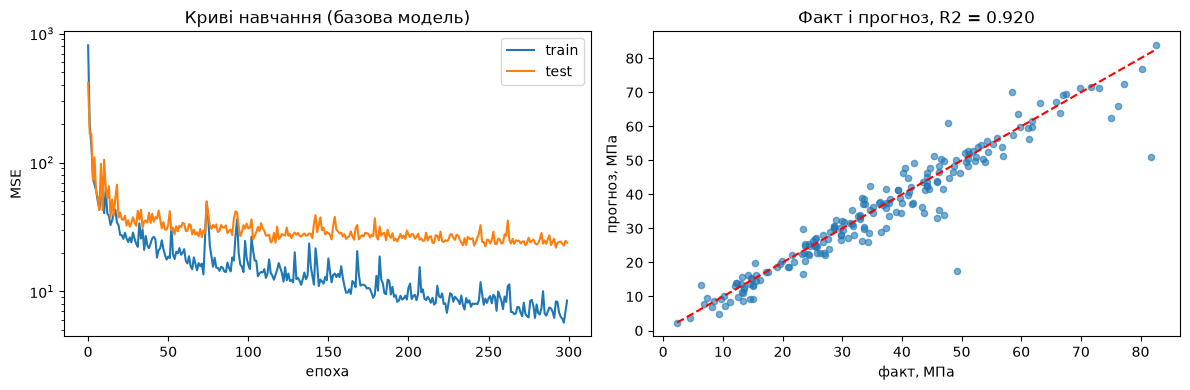

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(train_hist, label="train")
axes[0].plot(test_hist, label="test")
axes[0].set_xlabel("епоха")
axes[0].set_ylabel("MSE")
axes[0].set_yscale("log")
axes[0].legend()
axes[0].set_title("Криві навчання (базова модель)")

axes[1].scatter(y_test, pred_base, alpha=0.6, s=20)
lims = [float(y_test.min()), float(y_test.max())]
axes[1].plot(lims, lims, "r--")
axes[1].set_xlabel("факт, МПа")
axes[1].set_ylabel("прогноз, МПа")
axes[1].set_title(f"Факт і прогноз, R2 = {metrics_base['R2']:.3f}")

plt.tight_layout()
plt.show()

## Оптимізація

Пробую Adam замість SGD (адаптивний крок для кожного параметра, зазвичай швидше і
стабільніше сходиться на таких задачах) і глибшу мережу. Для найбільшої додаю
weight_decay як легку регуляризацію, датасет малий і перенавчання реальне.

In [13]:
experiments = {
    "SGD (64,32)":         dict(hidden=(64, 32),       opt="sgd",  lr=0.001, epochs=300, wd=0.0),
    "Adam (64,32)":        dict(hidden=(64, 32),       opt="adam", lr=1e-3,  epochs=300, wd=0.0),
    "Adam (128,64,32)":    dict(hidden=(128, 64, 32),  opt="adam", lr=1e-3,  epochs=500, wd=1e-4),
}

results, trained = {}, {}
for name, cfg in experiments.items():
    torch.manual_seed(SEED)
    m = ConcreteNet(len(feature_names), hidden=cfg["hidden"]).to(device)
    if cfg["opt"] == "sgd":
        opt = torch.optim.SGD(m.parameters(), lr=cfg["lr"], momentum=0.9, weight_decay=cfg["wd"])
    else:
        opt = torch.optim.Adam(m.parameters(), lr=cfg["lr"], weight_decay=cfg["wd"])
    print(f"--- {name}")
    hists = train(m, opt, cfg["epochs"], train_loader, log_every=cfg["epochs"] // 2)
    results[name], _ = evaluate(m)
    trained[name] = (m, hists)

pd.DataFrame(results).T.round(3)

--- SGD (64,32)
епоха    1 | train MSE   810.67 | test MSE   413.71
епоха  150 | train MSE    12.23 | test MSE    28.94
епоха  300 | train MSE     8.50 | test MSE    23.91
--- Adam (64,32)
епоха    1 | train MSE  1480.63 | test MSE  1562.87
епоха  150 | train MSE    30.35 | test MSE    43.13
епоха  300 | train MSE    19.38 | test MSE    34.84
--- Adam (128,64,32)
епоха    1 | train MSE  1440.62 | test MSE  1430.60
епоха  250 | train MSE    10.32 | test MSE    24.37
епоха  500 | train MSE     6.11 | test MSE    25.45


,MSE,MAE,R2
"SGD (64,32)",23.908,2.965,0.920
"Adam (64,32)",34.841,4.297,0.883
"Adam (128,64,32)",25.453,3.269,0.915


In [14]:
best_name = max(results, key=lambda k: results[k]["R2"])
best_model, (best_train_hist, best_test_hist) = trained[best_name]
metrics_best, pred_best = evaluate(best_model)
print("Найкраща модель:", best_name)
print({k: round(v, 3) for k, v in metrics_best.items()})

Найкраща модель: SGD (64,32)
{'MSE': 23.908, 'MAE': 2.965, 'R2': 0.92}


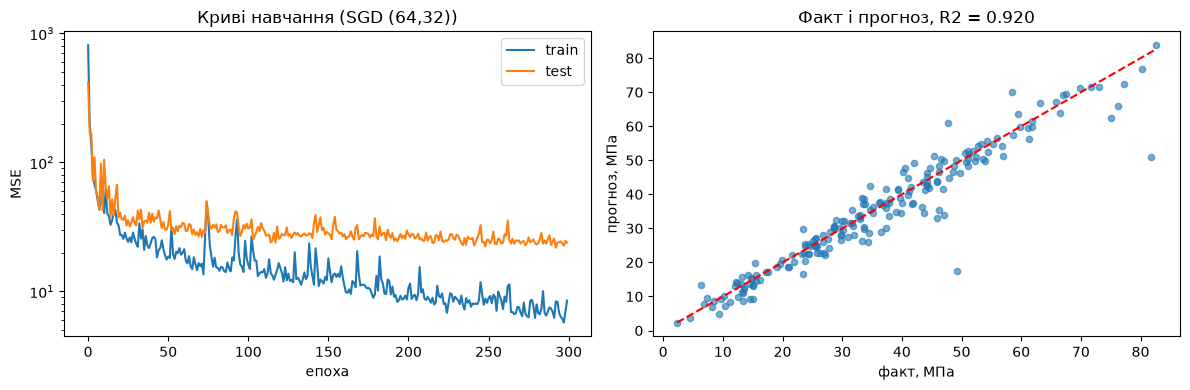

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(best_train_hist, label="train")
axes[0].plot(best_test_hist, label="test")
axes[0].set_xlabel("епоха")
axes[0].set_ylabel("MSE")
axes[0].set_yscale("log")
axes[0].legend()
axes[0].set_title(f"Криві навчання ({best_name})")

axes[1].scatter(y_test, pred_best, alpha=0.6, s=20)
lims = [float(y_test.min()), float(y_test.max())]
axes[1].plot(lims, lims, "r--")
axes[1].set_xlabel("факт, МПа")
axes[1].set_ylabel("прогноз, МПа")
axes[1].set_title(f"Факт і прогноз, R2 = {metrics_best['R2']:.3f}")

plt.tight_layout()
plt.show()

## Важливість факторів

Permutation importance: перемішую значення однієї ознаки на тесті і дивлюсь, наскільки
падає R². Чим більше падіння, тим сильніше модель спирається на цю ознаку. Метод не
залежить від типу моделі, на відміну від ваг першого шару.

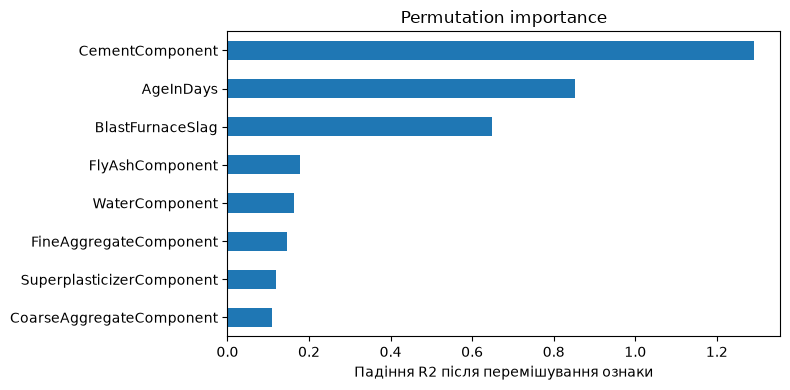

CementComponent              1.290
AgeInDays                    0.853
BlastFurnaceSlag             0.648
FlyAshComponent              0.178
WaterComponent               0.164
FineAggregateComponent       0.147
SuperplasticizerComponent    0.119
CoarseAggregateComponent     0.110
dtype: float64

In [16]:
def permutation_importance(model, X, y, n_repeats=20):
    model.eval()
    with torch.no_grad():
        base = r2_score(y, model(torch.tensor(X, device=device)).cpu().numpy())
    rng = np.random.default_rng(SEED)
    drops = {}
    for j, col in enumerate(feature_names):
        scores = []
        for _ in range(n_repeats):
            Xp = X.copy()
            rng.shuffle(Xp[:, j])
            with torch.no_grad():
                scores.append(r2_score(y, model(torch.tensor(Xp, device=device)).cpu().numpy()))
        drops[col] = base - np.mean(scores)
    return pd.Series(drops).sort_values()

importance = permutation_importance(best_model, X_test, y_test)

importance.plot.barh(figsize=(8, 4))
plt.xlabel("Падіння R2 після перемішування ознаки")
plt.title("Permutation importance")
plt.tight_layout()
plt.show()

importance.sort_values(ascending=False).round(3)

## Висновки

- Дані чисті: пропусків немає, 25 дублікатів прибрано, всі ознаки числові, тож із передобробки вистачило StandardScaler.
- Базова модель (MLP 8-64-32-1, SGD з momentum, lr 0.001, 300 епох) на тестовій вибірці, яка тут грає роль валідаційної: MSE 23.9, MAE 2.97 МПа, R² 0.920. Середня помилка близько 3 МПа при діапазоні цілі 2..82 МПа, для такої простої мережі це сильний результат.
- Експерименти: Adam з тією ж архітектурою за 300 епох дав лише R² 0.883, глибша мережа (128, 64, 32) з Adam і weight_decay дала 0.915, але в неї train MSE 6.1 проти test 25.5, вона вже помітно перенавчається. Висновок: на малому датасеті добре підібраний SGD не поступається складнішим варіантам, нарощувати мережу немає сенсу.
- Криві навчання базової моделі: train і test падають разом, розрив невеликий, критичного перенавчання немає.
- Найважливіші фактори за permutation importance: цемент (найбільше падіння R² після перемішування), далі вік бетону і доменний шлак. Вода, пластифікатор і заповнювачі впливають значно слабше. Це узгоджується з фізикою процесу: міцність росте з часткою цементу і з часом тверднення. Показово, що шлак у парних кореляціях був майже непомітний (0.10), а для моделі важливий, тобто його ефект нелінійний і проявляється у взаємодії з іншими компонентами. Саме такі речі кореляція не ловить, а нейромережа ловить.
- Обмеження: вибірка мала (близько 1000 зразків), метрики залежать від конкретного розбиття. Надійнішу оцінку дала б крос-валідація.